In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing:

In [2]:
filepath = "C:/Users/shanm/Python_Practice/Datasets/EastWestAirlines.xlsx"

In [3]:
airline = pd.read_excel(filepath , sheet_name="data")
airline.head(2)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0


In [4]:
airline2 = airline.copy()

In [5]:
airline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


All data types are number

In [6]:
airline.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [7]:
airline.isna().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

There are no null values

In [8]:
# We can remove ID column because it is not useful for clustering


airline = airline.drop("ID#", axis=1)
airline.head(1)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0


Lets visualize the data to understand the patterns

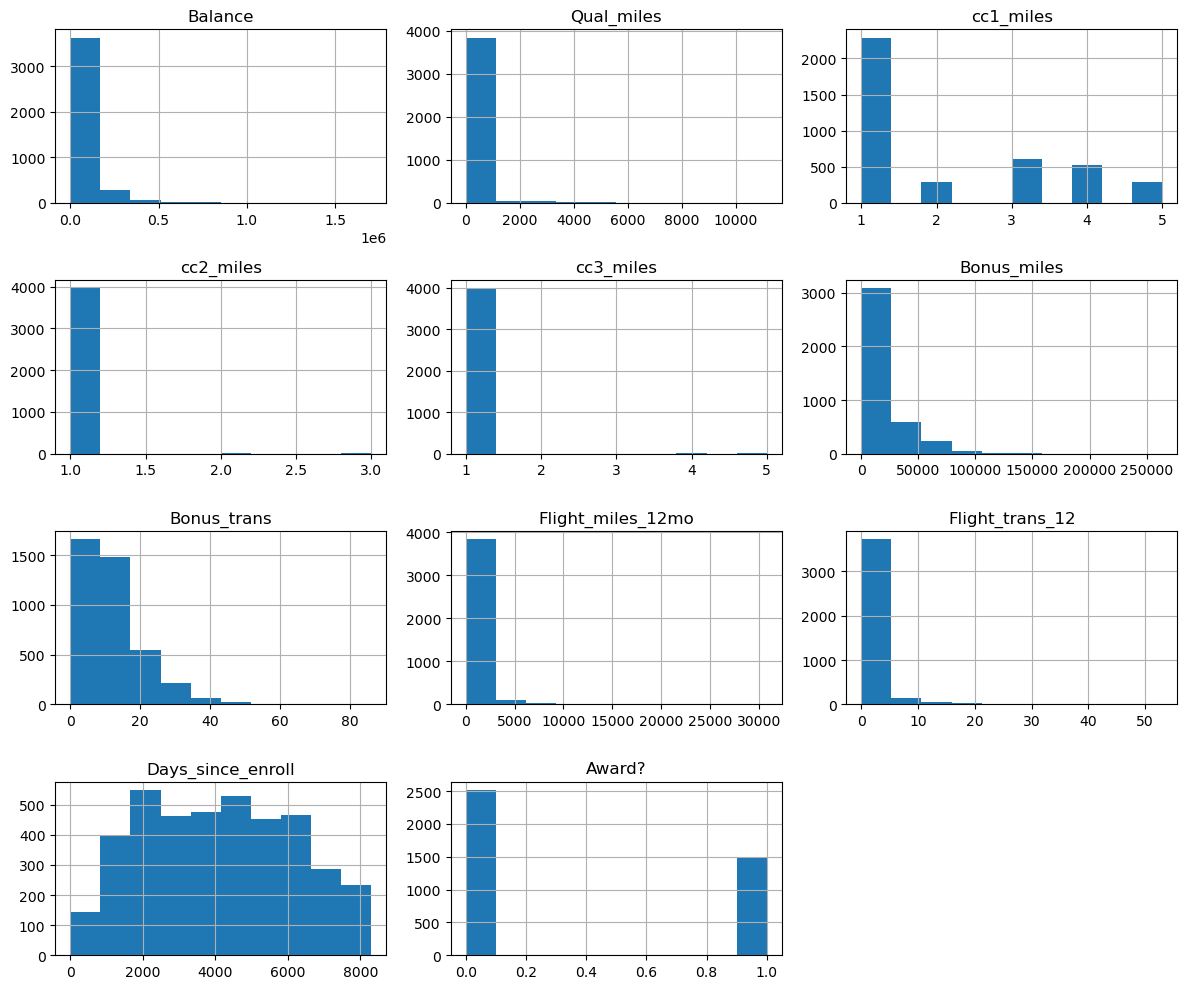

In [9]:
# Lets plot histogram

airline.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

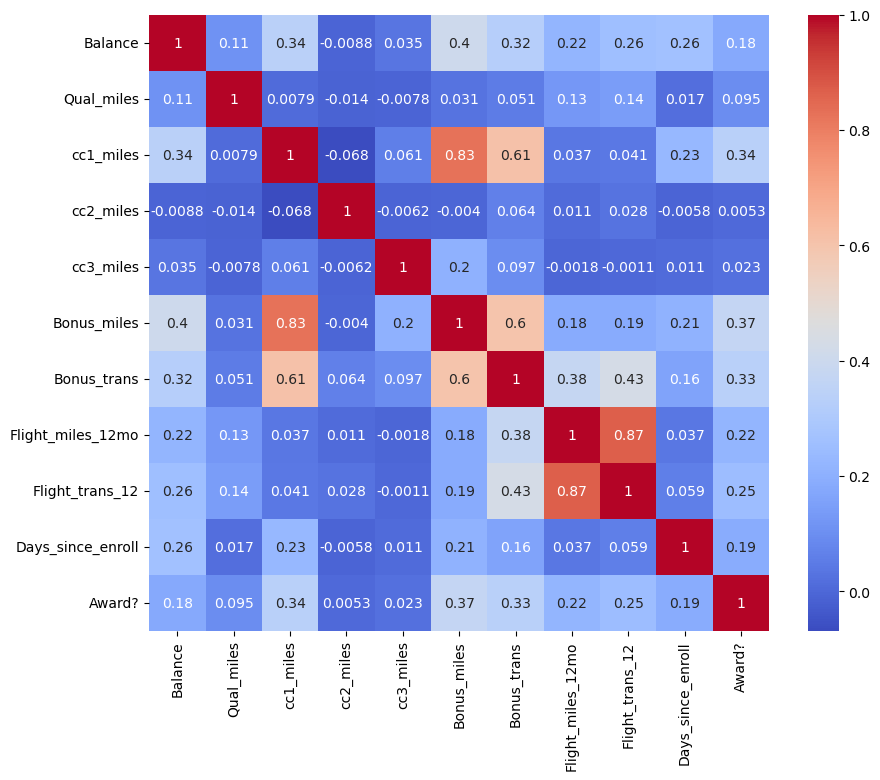

In [10]:
# Lets visualize heatmap

plt.figure(figsize=(10,8))
sns.heatmap(airline.corr(), annot=True, cmap='coolwarm')
plt.show()

Observations

- Bonus_miles and Bonus_trans with a high correlation, it means customers who earn more bonus miles also tend to have more bonus transactions.
- Flight_miles_12mo and Flight_trans_12 are likely strongly correlated, since more flights naturally lead to more transactions.
- Variables like Balance and Award? might show little to no correlation, meaning account balance doesn’t directly predict whether someone has received an award.
- Days_since_enroll may moderately correlate with Balance, suggesting longer-tenured customers tend to accumulate higher balances, but not always.

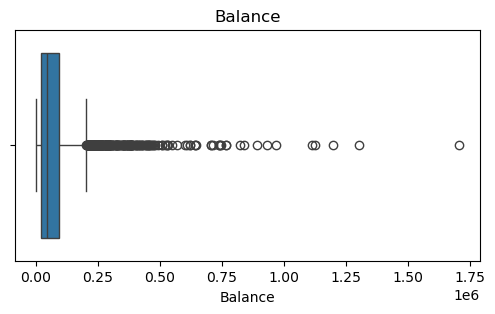

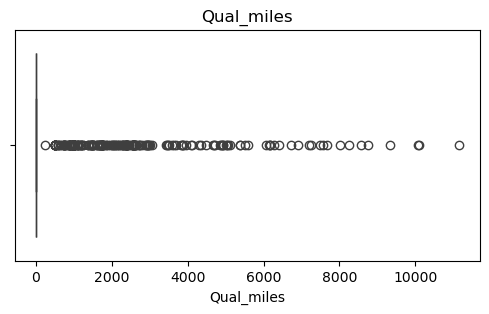

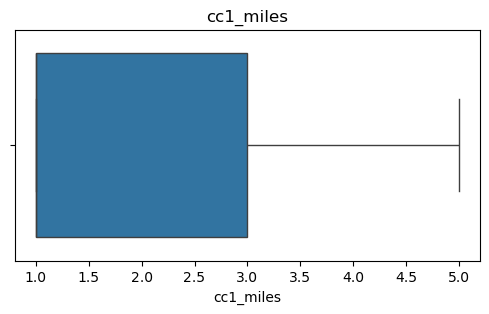

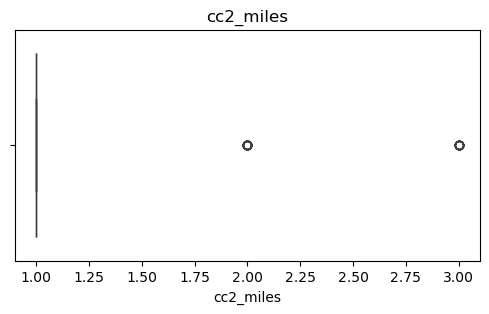

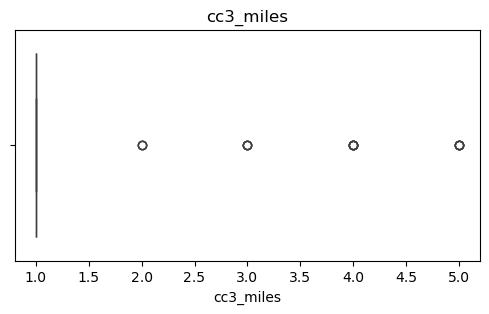

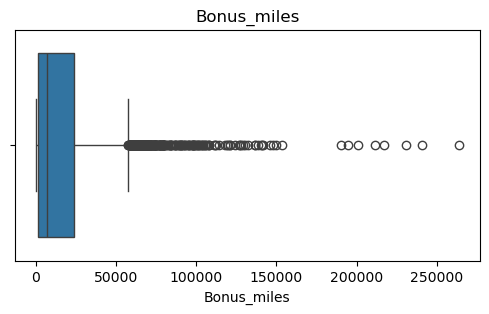

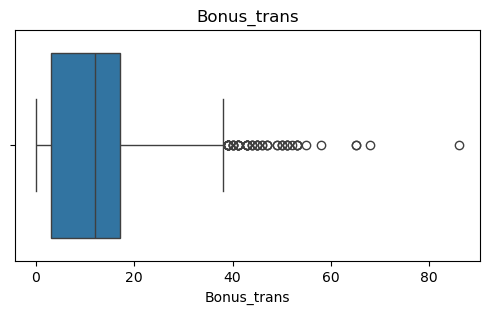

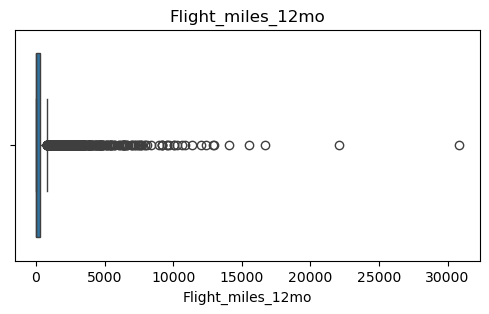

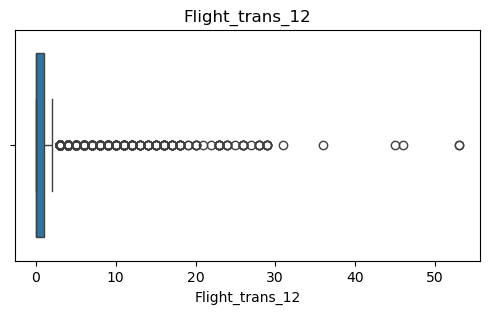

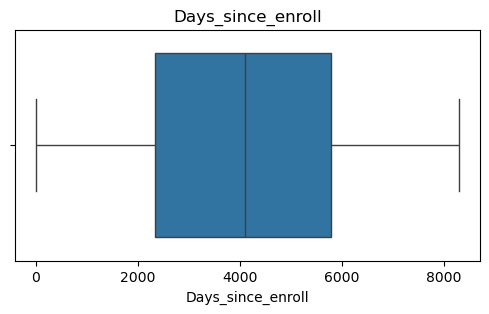

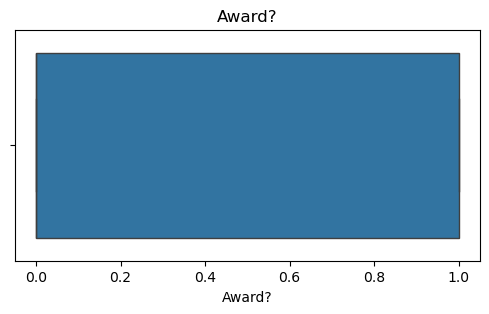

In [11]:
# Lets plot box plot to detect outliers if any

for col in airline.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    plt.title(f"{col}")
    sns.boxplot(x=airline[col])
    plt.show()

In [12]:
# Detecting Outliers

for col in airline.select_dtypes(include="number").columns:
    Q1 = airline[col].quantile(0.25)
    Q3 = airline[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = airline[(airline[col] < lower) | (airline[col] > upper)]
    print(f"{col} outliers : {len(outliers)}")


Balance outliers : 266
Qual_miles outliers : 226
cc1_miles outliers : 0
cc2_miles outliers : 43
cc3_miles outliers : 18
Bonus_miles outliers : 280
Bonus_trans outliers : 63
Flight_miles_12mo outliers : 569
Flight_trans_12 outliers : 565
Days_since_enroll outliers : 0
Award? outliers : 0


In [13]:
# Lets cap outliers 

# ["Balance", "Bonus_miles", "Flight_miles_12mo", "Flight_trans_12"] these columns have hevay outliers lets cap them


def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

for col in ["Balance", "Bonus_miles", "Flight_miles_12mo", "Flight_trans_12"]:
    cap_outliers(airline, col)

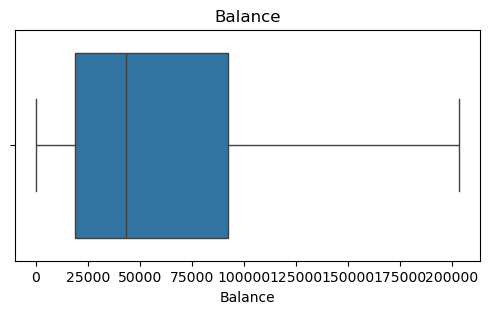

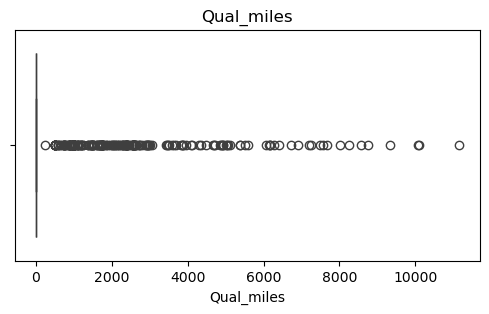

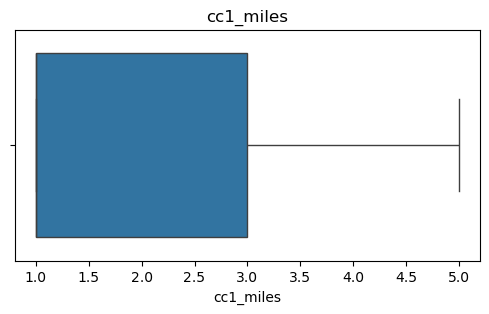

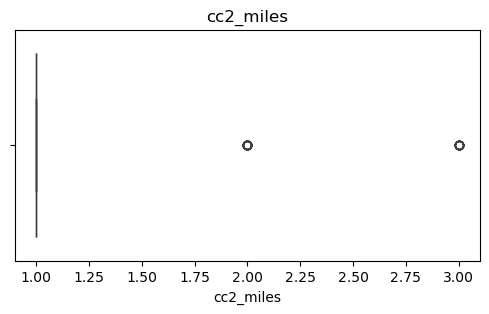

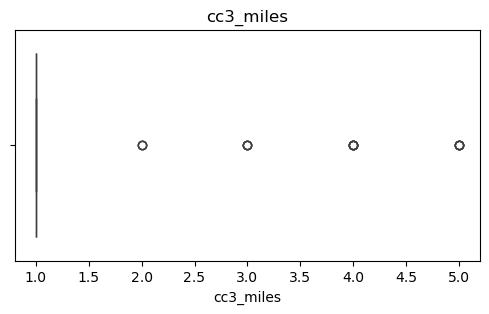

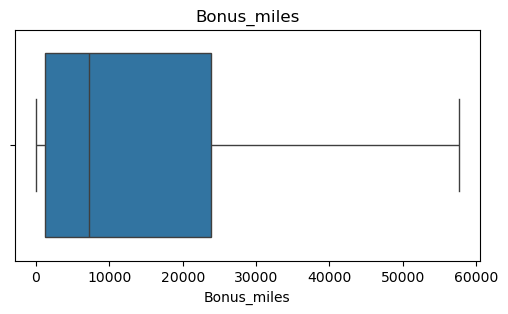

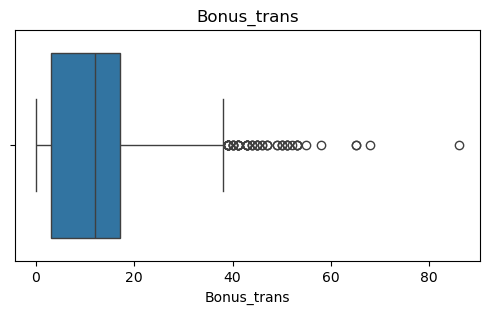

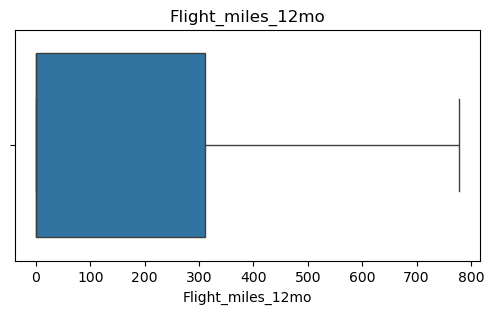

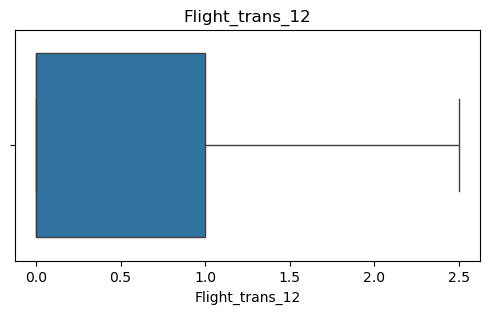

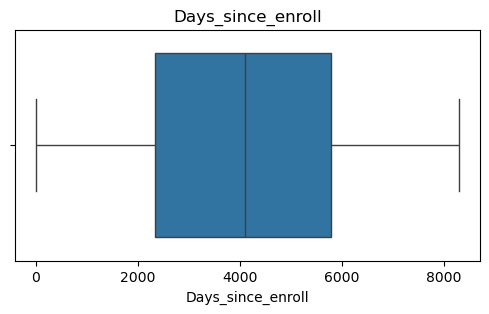

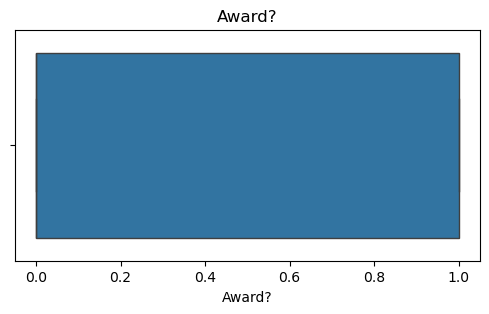

In [14]:
# Lets plot box plot to detect outliers if any

for col in airline.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    plt.title(f"{col}")
    sns.boxplot(x=airline[col])
    plt.show()

Outliers were analyzed for each feature using the IQR method. Instead of removing all outliers, a feature-wise strategy was applied. For highly skewed variables such as Balance, Bonus Miles, and Flight-related features, outliers were capped to preserve important customer segments while reducing extreme values. This approach ensured that meaningful patterns were retained while improving clustering performance.

In [15]:
# Scaling features 

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(airline)

Lets apply Log transformation to scaled values

In [16]:
for col in ["Balance", "Bonus_miles", "Flight_miles_12mo", "Flight_trans_12"]:
    airline[col] = np.log1p(airline[col])

# Implementing Clustering Algorithms:

## 1.Implementing KMeans

Lets find number of clusters using Elbow method (To find optimal k)

#### Hyperparameter Tuning Using Elbow Plot

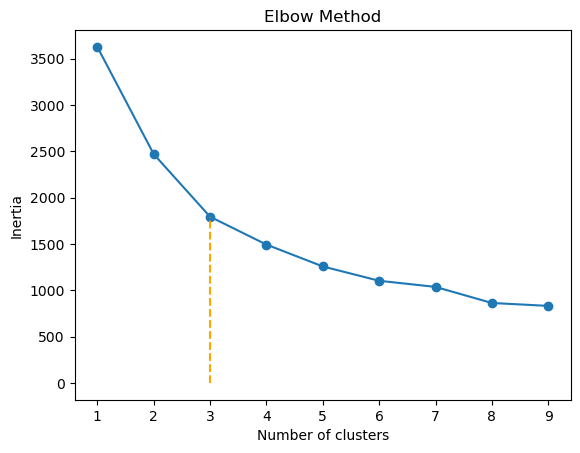

In [17]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.vlines(x=3, ymin=0,ymax=inertia[2], linestyles='dashed', colors='orange')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

As per Elbow method, 3 is the optimal number clusters

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

airline['KMeans_Cluster'] = kmeans_labels

# Evaluation and Performance Metrics:

Evaluating KMeans Clusters

In [19]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(scaled_data, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)


K-Means Silhouette Score: 0.38797631857430676


# Visualization:

Visualizing Clusters

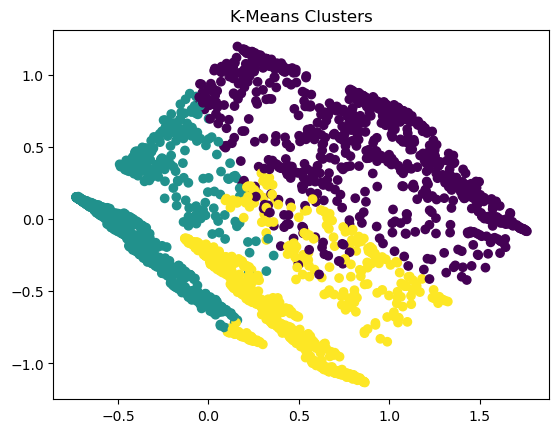

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clusters")
plt.show()

## Analysis

Cluster 1 (Purple - upper region)
- Higher values in principal components
- Likely high activity / high-value customers

Cluster 2 (Teal - left region)
- Lower values
- Likely low engagement customers

Cluster 3 (Yellow - bottom region)
- Moderate but distinct behavior
- Possibly medium usage customers

The clusters appear elongated and partially overlapping, indicating that the dataset does not form perfectly spherical clusters. The K-Means clustering algorithm was able to identify three meaningful clusters within the dataset. However, the clusters are not perfectly separated and exhibit some overlap, as seen in the visualization. The elongated shape of clusters suggests that the data may contain correlated features and does not strictly follow the spherical cluster assumption of K-Means. Despite this, the clustering provides useful segmentation of the data.

## 2.Implementing DBSCAN

In [21]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=10)
dbscan.fit(scaled_data)

DBSCAN(eps=1.0, min_samples=10)

In [22]:
dbscan_labels = dbscan.labels_
dbscan_labels

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [23]:
airline2['labels'] = dbscan.labels_
airline2.head(2)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,labels
0,1,28143,0,1,1,1,174,1,0,0,7000,0,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0,0


# Evaluation and Performance Metrics:

In [24]:
silhouette_score(airline2.drop('labels', axis=1), airline2['labels'])

0.12930574984706272

# Visualization:

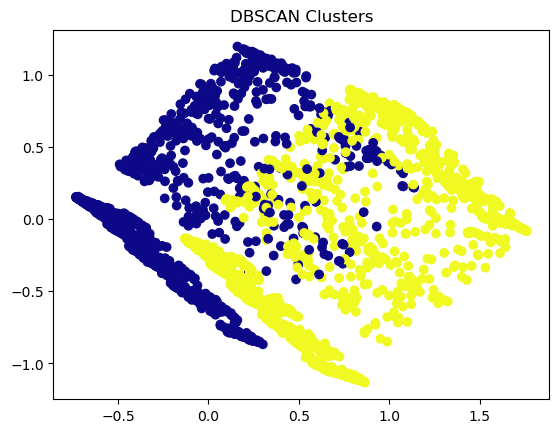

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_data)


plt.scatter(pca_data[:,0], pca_data[:,1], c=airline2['labels'], cmap='plasma')
plt.title("DBSCAN Clusters")
plt.show()

Observation:

- Data not suited for density-based clustering
- DBSCAN works best when: Clusters are dense and well-separated
- Airline dataset likely has: Gradual variations , better for K-Means


# Cluster Analysis and Interpretation:


- Cluster 0: Customers with high balance and high bonus miles are frequent flyers
- Cluster 1: Low balance, low activity means inactive customers
- Cluster 2: Moderate balance with high flight transactions shows regular travelers

DBSCAN observations:
- Identifies dense groups and marks unusual data as noise
- Useful for detecting outliers (e.g., rare high-mile users)

K-Means
- Works well for clearly separated clusters
- Needs predefined K
- Sensitive to scaling

DBSCAN
- Detects arbitrary-shaped clusters
- Automatically finds number of clusters
- Handles noise better

In our dataset , KMeans works well with comparatively high Silhouette score (0.38), which makes a good cluster for our airline dataset whereas DBScan works poorly with silhouette score of 0.21